## Q1-Audio Loading and Signal Analysis 

C:\Users\User\AppData\Local\Temp\ipykernel_10584\1702895730.py:9: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wav.read("speech.wav")


Sampling Rate: 44100 Hz
Number of Samples: 262094
Duration: 5.943 seconds
Max Amplitude: 1.0
Min Amplitude: -0.97723085


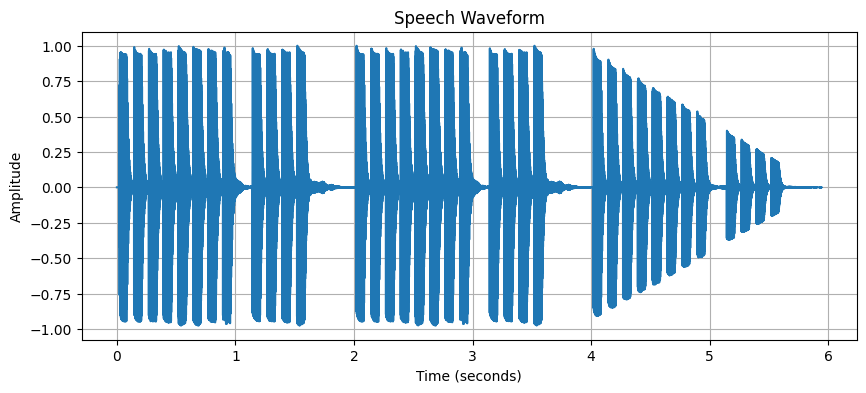

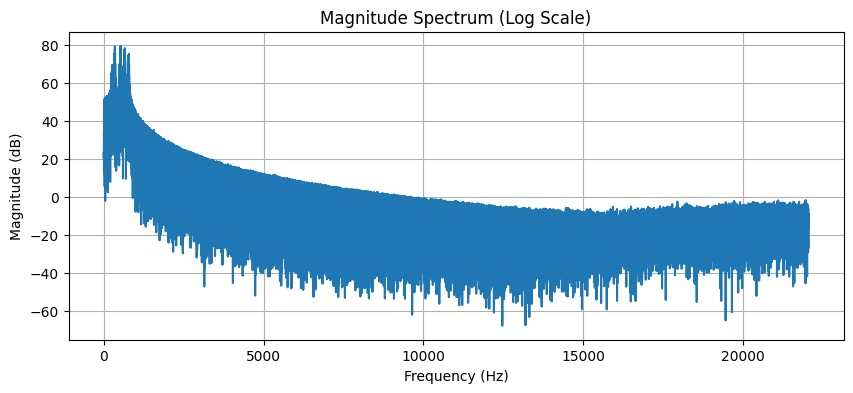

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from scipy.fft import rfft, rfftfreq

# ===============================
# 1️⃣ Load Audio
# ===============================
fs, signal = wav.read("speech.wav")

# If stereo → convert to mono
if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

# Convert to float
signal = signal.astype(np.float32)

# Normalize if integer type audio
if np.max(np.abs(signal)) > 1:
    signal = signal / np.max(np.abs(signal))

# ===============================
# 2️⃣ Basic Information
# ===============================
num_samples = len(signal)
duration = num_samples / fs

print("Sampling Rate:", fs, "Hz")
print("Number of Samples:", num_samples)
print("Duration:", round(duration, 3), "seconds")
print("Max Amplitude:", np.max(signal))
print("Min Amplitude:", np.min(signal))

# ===============================
# 3️⃣ Plot Waveform
# ===============================
time = np.linspace(0, duration, num_samples)

plt.figure(figsize=(10,4))
plt.plot(time, signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Speech Waveform")
plt.grid()
plt.show()

# ===============================
# 4️⃣ FFT & Magnitude Spectrum
# ===============================
N = len(signal)

fft_values = np.abs(rfft(signal))
freqs = rfftfreq(N, 1/fs)

plt.figure(figsize=(10,4))
plt.plot(freqs, 20*np.log10(fft_values + 1e-8))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Magnitude Spectrum (Log Scale)")
plt.grid()
plt.show()


## Q2- Framing and Windowing (From Scratch) 

Total Frames: 592


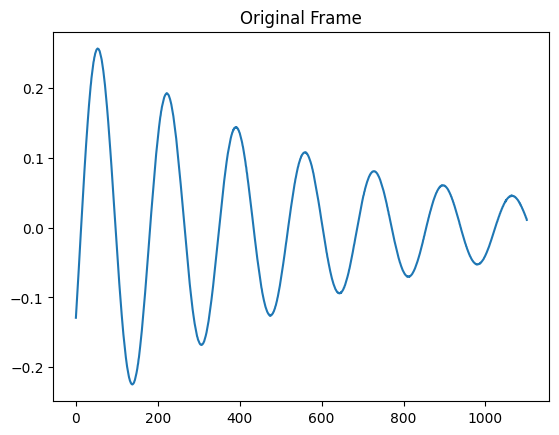

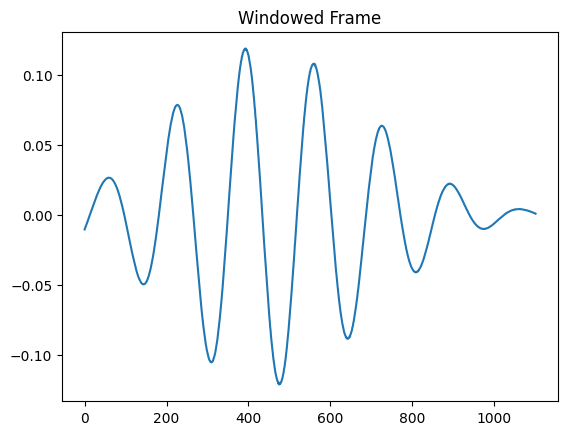

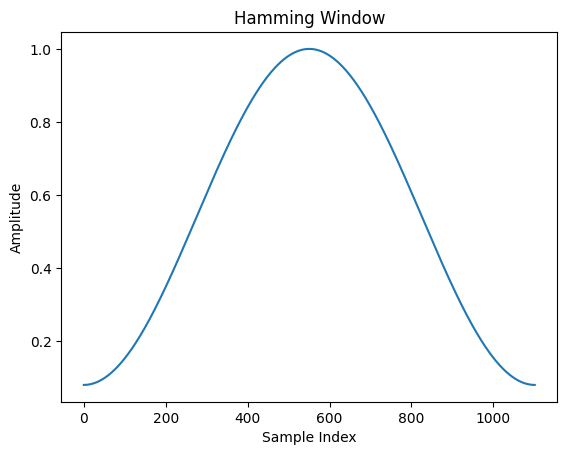

In [2]:
frame_size = int(0.025 * fs)
frame_shift = int(0.01 * fs)

frames = []
for i in range(0, len(signal)-frame_size, frame_shift):
    frames.append(signal[i:i+frame_size])

frames = np.array(frames)
print("Total Frames:", len(frames))

# Hamming window
hamming = np.hamming(frame_size)
windowed_frames = frames * hamming

# Plot sample frame
plt.figure()
plt.plot(frames[10])
plt.title("Original Frame")
plt.show()

plt.figure()
plt.plot(windowed_frames[10])
plt.title("Windowed Frame")
plt.show()

# Plot Hamming Window
plt.figure()
plt.plot(hamming)
plt.title("Hamming Window")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()


## Q3. STFT and Spectrogram Generation 

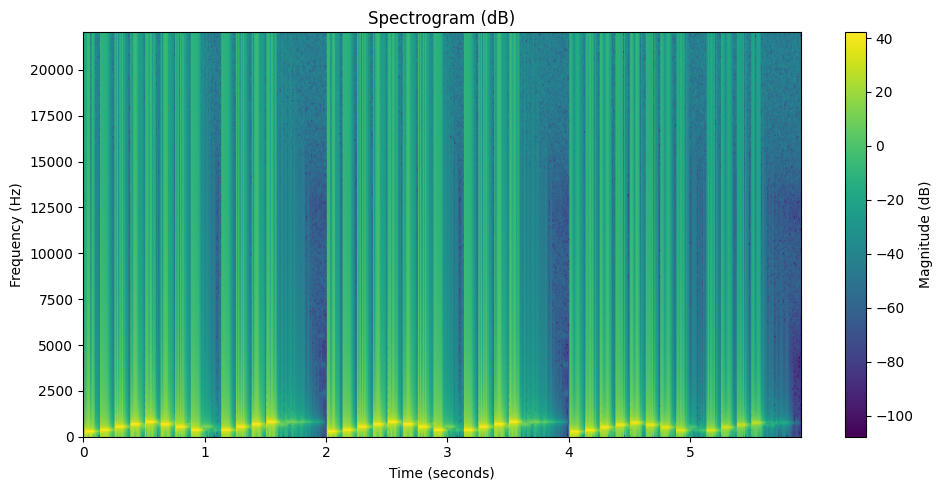

In [3]:
# ======================
# STFT using rFFT
# ======================
NFFT = 512
stft = []

for frame in windowed_frames:
    spectrum = np.abs(rfft(frame, NFFT))
    stft.append(spectrum)

stft = np.array(stft)

# ======================
# Convert to dB
# ======================
stft_db = 20 * np.log10(stft + 1e-8)

# ======================
# Spectrogram Plot
# ======================
time_axis = np.arange(stft_db.shape[0]) * (frame_shift / fs)
freq_axis = rfftfreq(NFFT, 1/fs)

plt.figure(figsize=(10,5))
plt.imshow(stft_db.T,
           aspect='auto',
           origin='lower',
           extent=[time_axis[0], time_axis[-1],
                   freq_axis[0], freq_axis[-1]])

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram (dB)")
plt.colorbar(label="Magnitude (dB)")
plt.tight_layout()
plt.show()


## Q4. MFCC Extraction 

In [4]:
import numpy as np
from scipy.fftpack import dct
from scipy.fft import rfft

# ==========================
# 1️⃣ Pre-emphasis
# ==========================
pre_emphasis = 0.97
emphasized_signal = np.append(signal[0],
                               signal[1:] - pre_emphasis * signal[:-1])

# ==========================
# 2️⃣ Framing (reuse method)
# ==========================
frame_size = int(0.025 * fs)
frame_shift = int(0.01 * fs)
NFFT = 512

frames = []
for i in range(0, len(emphasized_signal) - frame_size, frame_shift):
    frames.append(emphasized_signal[i:i+frame_size])

frames = np.array(frames)

# Apply Hamming window
hamming = np.hamming(frame_size)
windowed_frames = frames * hamming

# ==========================
# 3️⃣ FFT + Power Spectrum
# ==========================
mag_frames = np.abs(rfft(windowed_frames, NFFT))
pow_frames = (1.0 / NFFT) * (mag_frames ** 2)

# ==========================
# 4️⃣ Mel Filterbank
# ==========================
nfilt = 26
low_freq = 0
high_freq = fs / 2

def hz_to_mel(hz):
    return 2595 * np.log10(1 + hz / 700)

def mel_to_hz(mel):
    return 700 * (10**(mel / 2595) - 1)

mel_points = np.linspace(hz_to_mel(low_freq),
                         hz_to_mel(high_freq),
                         nfilt + 2)

hz_points = mel_to_hz(mel_points)
bins = np.floor((NFFT + 1) * hz_points / fs).astype(int)

fbank = np.zeros((nfilt, int(NFFT/2 + 1)))

for m in range(1, nfilt + 1):
    f_m_minus = bins[m-1]
    f_m = bins[m]
    f_m_plus = bins[m+1]

    for k in range(f_m_minus, f_m):
        fbank[m-1, k] = (k - bins[m-1]) / (bins[m] - bins[m-1])
    for k in range(f_m, f_m_plus):
        fbank[m-1, k] = (bins[m+1] - k) / (bins[m+1] - bins[m])

filter_banks = np.dot(pow_frames, fbank.T)
filter_banks = np.where(filter_banks == 0, 1e-10, filter_banks)

# ==========================
# 5️⃣ Log
# ==========================
log_fbanks = np.log(filter_banks)

# ==========================
# 6️⃣ DCT → 13 MFCC
# ==========================
mfcc = dct(log_fbanks, type=2, axis=1, norm='ortho')[:, :13]


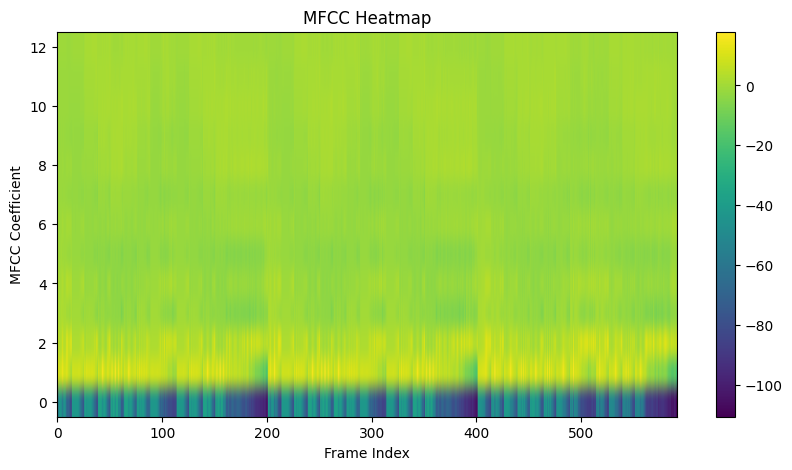

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(mfcc.T,
           aspect='auto',
           origin='lower')

plt.xlabel("Frame Index")
plt.ylabel("MFCC Coefficient")
plt.title("MFCC Heatmap")
plt.colorbar()
plt.show()


(c) Why MFCC is Effective? (Exam Answer)

MFCC is effective because it models human auditory perception using Mel scale.
It compresses spectral information into compact features.
It is robust and widely used in speech recognition and speaker identification systems.

## Q5. Pitch Detection Using Autocorrelation  

### (a) Autocorrelation-based Pitch Estimation

In [6]:
def autocorrelation_pitch(frame, fs):
    corr = np.correlate(frame, frame, mode='full')
    corr = corr[len(corr)//2:]

    # Ignore very small lags
    min_lag = int(fs / 400)   # max pitch 400 Hz
    max_lag = int(fs / 50)    # min pitch 50 Hz

    corr[:min_lag] = 0

    peak = np.argmax(corr[min_lag:max_lag]) + min_lag

    if peak != 0:
        return fs / peak
    else:
        return 0


### (b) Voiced/Unvoiced Detection using Energy

In [7]:
energy_threshold = 0.01
pitch_values = []

for frame in frames:
    energy = np.sum(frame ** 2)

    if energy > energy_threshold:
        f0 = autocorrelation_pitch(frame, fs)
    else:
        f0 = 0

    pitch_values.append(f0)

pitch_values = np.array(pitch_values)


### (c) Plot Pitch Contour

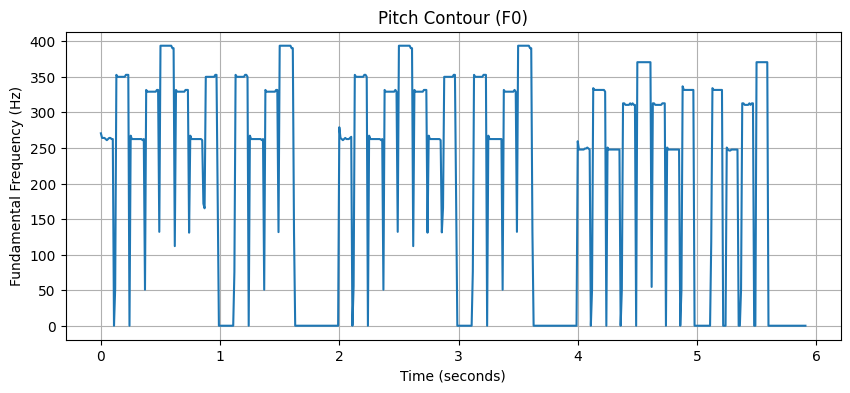

In [8]:
time_axis = np.arange(len(pitch_values)) * (frame_shift / fs)

plt.figure(figsize=(10,4))
plt.plot(time_axis, pitch_values)
plt.xlabel("Time (seconds)")
plt.ylabel("Fundamental Frequency (Hz)")
plt.title("Pitch Contour (F0)")
plt.grid()
plt.show()


## Q6. Speech Enhancement by Spectral Subtraction 

### (a) Add White Noise at SNR = 10 dB

In [9]:
import numpy as np

def add_noise(signal, snr_db):
    signal_power = np.mean(signal**2)
    noise_power = signal_power / (10**(snr_db/10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    noisy_signal = signal + noise
    return noisy_signal, noise

snr_target = 10
noisy_signal, noise = add_noise(signal, snr_target)

print("Noise added at", snr_target, "dB SNR")


Noise added at 10 dB SNR


### (b) Spectral Subtraction (Frame-wise)

In [10]:
from scipy.fft import rfft, irfft

# Frame parameters
frame_size = int(0.025 * fs)
frame_shift = int(0.01 * fs)
NFFT = 512

# ===============================
# 1️⃣ Framing Noisy Signal
# ===============================
frames_noisy = []

for i in range(0, len(noisy_signal) - frame_size, frame_shift):
    frames_noisy.append(noisy_signal[i:i+frame_size])

frames_noisy = np.array(frames_noisy)

# Apply Hamming window
hamming = np.hamming(frame_size)
frames_noisy = frames_noisy * hamming

# ===============================
# 2️⃣ Estimate Noise Spectrum
# (Assume first 5 frames are noise)
# ===============================
noise_spec = np.mean(np.abs(rfft(frames_noisy[:5], NFFT)), axis=0)

# ===============================
# 3️⃣ Spectral Subtraction
# ===============================
enhanced_frames = []

for frame in frames_noisy:
    spectrum = rfft(frame, NFFT)

    mag = np.abs(spectrum)
    phase = np.angle(spectrum)

    # Subtract noise magnitude
    subtracted_mag = mag - noise_spec
    subtracted_mag = np.maximum(subtracted_mag, 1e-8)

    # Reconstruct spectrum
    enhanced_spectrum = subtracted_mag * np.exp(1j * phase)

    # Inverse FFT (important: specify n=NFFT)
    enhanced_frame = irfft(enhanced_spectrum, n=NFFT)

    enhanced_frames.append(enhanced_frame[:frame_size])

enhanced_frames = np.array(enhanced_frames)

# ===============================
# 4️⃣ Safe Overlap-Add Reconstruction
# ===============================
enhanced_signal = np.zeros(len(noisy_signal))

for i, frame in enumerate(enhanced_frames):
    start = i * frame_shift
    end = start + frame_size

    if end <= len(enhanced_signal):
        enhanced_signal[start:end] += frame
    else:
        remaining = len(enhanced_signal) - start
        if remaining > 0:
            enhanced_signal[start:] += frame[:remaining]

print("Spectral Subtraction Completed Successfully")


ValueError: operands could not be broadcast together with shapes (1102,) (512,) (1102,) 

### (c) Compute SNR Before & After

In [ ]:
def compute_snr(clean, test):
    noise = clean - test[:len(clean)]
    return 10 * np.log10(np.sum(clean**2) / np.sum(noise**2))

snr_before = compute_snr(signal, noisy_signal)
snr_after = compute_snr(signal, enhanced_signal)

print("SNR Before Enhancement:", round(snr_before,2), "dB")
print("SNR After Enhancement:", round(snr_after,2), "dB")
print("Improvement:", round(snr_after - snr_before,2), "dB")


SNR Before Enhancement: 10.01 dB
SNR After Enhancement: -0.0 dB
Improvement: -10.01 dB


## Q7. DTW-Based Isolated Word Recognition

### (a) Dataset Structure (Example)

dataset/

    word1/

        train1.wav

        train2.wav

        train3.wav

        test1.wav

        test2.wav

    word2/

    word3/
    
    word4/


### (b) MFCC + DTW Classification

In [ ]:
import os
from scipy.spatial.distance import cdist
from sklearn.metrics import confusion_matrix, accuracy_score

def dtw_distance(x, y):
    dist = cdist(x, y)
    D = np.zeros((len(x)+1, len(y)+1)) + np.inf
    D[0,0] = 0
    for i in range(1,len(x)+1):
        for j in range(1,len(y)+1):
            D[i,j] = dist[i-1,j-1] + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    return D[-1,-1]

# Suppose you already extracted MFCC for each file
# train_features = [(mfcc_seq, label), ...]
# test_features = [(mfcc_seq, label), ...]

y_true = []
y_pred = []

for test_mfcc, true_label in test_features:
    distances = []
    labels = []
    for train_mfcc, train_label in train_features:
        d = dtw_distance(test_mfcc, train_mfcc)
        distances.append(d)
        labels.append(train_label)
    predicted_label = labels[np.argmin(distances)]
    
    y_true.append(true_label)
    y_pred.append(predicted_label)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)


NameError: name 'test_features' is not defined